# Extract Features

This tutorials present a step-by-step set of instructions on how to extract a set of *Radiomics* from a specified DCE-MRI and its corresponding tumor mask.

In addition, we present a set of instructions to extract a set of *RadioDynamics* from the same DCE-MRI.

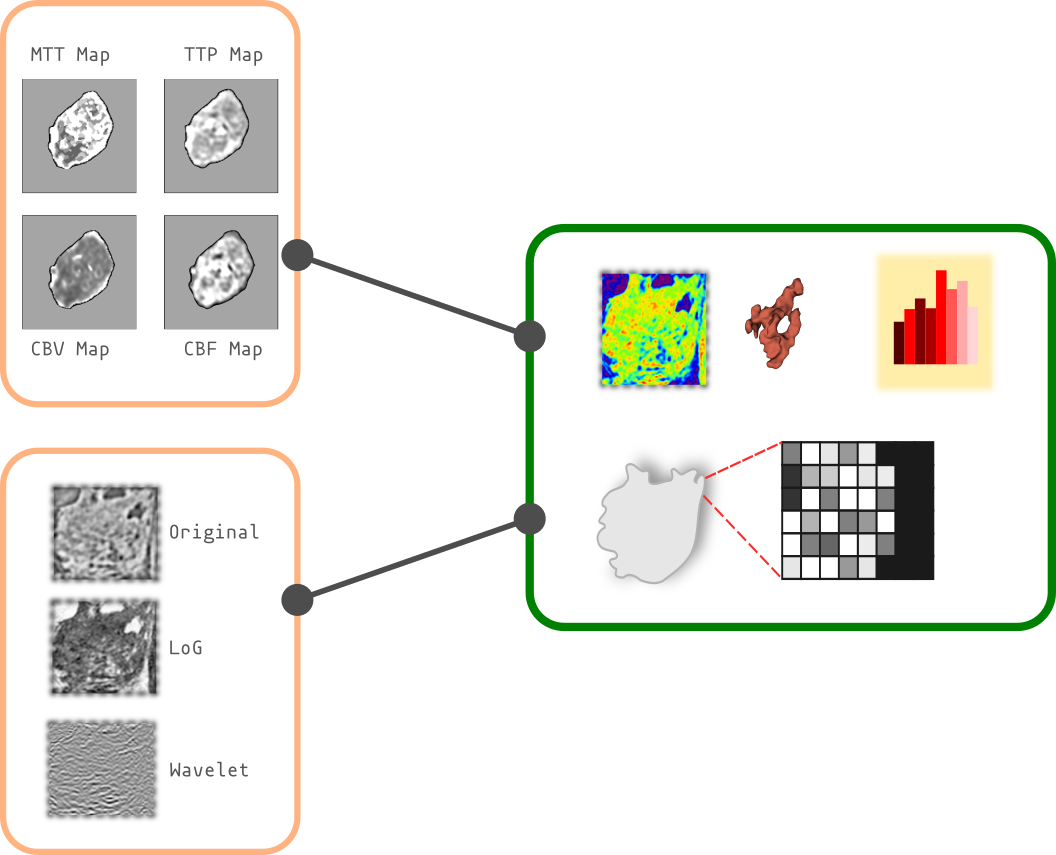

<a target="_blank" href="https://colab.research.google.com/github/MAIA-KTH/Hive_ML/blob/master/tutorials/1-Extract_Features.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
from radiomics import featureextractor
import json
import logging
import yaml
import radiomics
import six
import Hive_ML.configs
radiomics.logger.setLevel(logging.ERROR)
from importlib.resources import as_file, files
from pathlib import Path
import SimpleITK as sitk
import pandas as pd
from Hive_ML.data_loader.image_loader import get_id_label
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## Set Feature Parameter and Configuration file paths

*feature_param_file* file is used by **pyradiomics** to configure the extractor, while *config_file* contains experiment parameters.

In [ ]:
feature_param_file = "radiomic_original_params.yaml"
config_file = "MAMAMIA_Radiodynamics_config.json"

try:
    with open(config_file) as json_file:
        config_dict = json.load(json_file)
except FileNotFoundError:
    with as_file(files(Hive_ML.configs).joinpath(config_file)) as json_path:
        with open(json_path) as json_file:
            config_dict = json.load(json_file)

try:
    extractor = featureextractor.RadiomicsFeatureExtractor(feature_param_file)
except:
    with as_file(files(Hive_ML.configs).joinpath(feature_param_file)) as file:
        extractor = featureextractor.RadiomicsFeatureExtractor(str(file))


In [ ]:
print(json.dumps(config_dict, indent=2))

In [ ]:
with open(file, 'r') as stream:
    d=yaml.safe_load(stream)
    print(json.dumps(d, indent=2))

## Extract Radiomics for one example case

In [ ]:
data_folder = "Data/MAMA-MIA/Classes"

image_suffix = config_dict["image_suffix"]
mask_suffix = config_dict["mask_suffix"]
patient_class = "pCR"
patient_id = "DUKE_005"

In [ ]:
image_filename = str(Path(data_folder).joinpath(patient_class, patient_id,patient_id+image_suffix))
mask_filename = str(Path(data_folder).joinpath(patient_class,patient_id, patient_id+mask_suffix))

## Load DCE-MRI and Extract Patient ID and PCR Class

In [ ]:
img = sitk.ReadImage(image_filename)

subject_ID, label = get_id_label(image_filename, config_dict)

## Generate list of 3D MRI from original DCE-MRI

In [ ]:

def get_3D_image_sequence_list_from_4D_image(image_filename):
    itk_image = sitk.ReadImage(image_filename)
    img_array = sitk.GetArrayFromImage(itk_image)

    n_sequence = itk_image.GetSize()[-1]
    direction_3D = itk_image.GetDirection()[:3] + itk_image.GetDirection()[4:7] + itk_image.GetDirection()[8:11]
    origin = itk_image.GetOrigin()[:3]
    spacing = itk_image.GetSpacing()[:3]

    sitk_3D_image_sequences = []
    for sequence in range(n_sequence):
        img_sequence = img_array[sequence]
        itk_img_sequence = sitk.GetImageFromArray(img_sequence)
        itk_img_sequence.SetOrigin(origin)
        itk_img_sequence.SetSpacing(spacing)
        itk_img_sequence.SetDirection(direction_3D)
        sitk_3D_image_sequences.append(itk_img_sequence)

    return sitk_3D_image_sequences

sitk_3D_image_sequence_list = get_3D_image_sequence_list_from_4D_image(image_filename)

In [ ]:
image_filenames = [ Path(data_folder).joinpath(patient_class, patient_id,patient_id+config_dict["perfusion_maps"][perfusion_map]) for perfusion_map in config_dict["perfusion_maps"] ]

sitk_3D_image_sequence_list = [ sitk.ReadImage(image_filename) for image_filename in image_filenames ]

## Load and Binarize Tumor Mask

In [ ]:
sitk_mask = sitk.ReadImage(mask_filename)
mask_array = sitk.GetArrayFromImage(sitk_mask)
mask_array[mask_array>0] = 1
sitk_mask_thresholded = sitk.GetImageFromArray(mask_array)
sitk_mask_thresholded.CopyInformation(sitk_mask)

## Extract Radiomics

In [ ]:
image_types_dict = extractor.enabledImagetypes
image_types = [x.lower() for x in image_types_dict]

radiomics = []
    
for sequence_number, itk_3D_image in enumerate(sitk_3D_image_sequence_list):
    if itk_3D_image is None:
        features_map = {"Subject_ID": subject_ID, "Subject_Label": label, "Sequence_Number": sequence_number}
    else:
        if itk_3D_image.GetSize() != sitk_mask.GetSize():
            continue
        features = extractor.execute(itk_3D_image, sitk_mask_thresholded)
        features_map = {"Subject_ID": subject_ID, "Subject_Label": label, "Sequence_Number": sequence_number}
        for key, val in six.iteritems(features):
            if key.startswith(tuple(image_types)):
                features_map[key] = features[key]
        radiomics.append(features_map)

### Create Pandas DataFrame for extracted radiomics

In [ ]:
features_df = []

for feature_sequence in radiomics:
    features_df.append(feature_sequence)
    
features_df_radiomics = pd.DataFrame.from_records(features_df)

In [ ]:
features_df_radiomics.iloc[: , :8]

## Load RadioDynamics Configuration

In [ ]:
config_file = "Radiodynamics_config.json"

try:
    with open(config_file) as json_file:
        config_dict = json.load(json_file)
except FileNotFoundError:
    with as_file(files(Hive_ML.configs).joinpath(config_file)) as json_path:
        with open(json_path) as json_file:
            config_dict = json.load(json_file)

In [ ]:
print(json.dumps(config_dict, indent=2))

## Extract Radiodynamics for one example case

In [ ]:
data_folder = "Data/DCE_MRI_dataset"

image_suffix = config_dict["image_suffix"]
mask_suffix = config_dict["mask_suffix"]
patient_class = "pCR"
patient_id = "Patient09"

In [ ]:
image_filename = [ str(Path(data_folder).joinpath(patient_class, patient_id,patient_id+suffix)) for suffix in image_suffix ]
mask_filename = str(Path(data_folder).joinpath(patient_class,patient_id, patient_id+mask_suffix))

In [ ]:
sitk_3D_image_sequence_list = []
for single_image_filename in image_filename:
    img = sitk.ReadImage(single_image_filename)
    sitk_3D_image_sequence_list.append(img)

## Extract Radiodynamics

In [ ]:
image_types_dict = extractor.enabledImagetypes
image_types = [x.lower() for x in image_types_dict]

radiodynamics = []
    
for sequence_number, itk_3D_image in enumerate(sitk_3D_image_sequence_list):
    if itk_3D_image is None:
        features_map = {"Subject_ID": subject_ID, "Subject_Label": label, "Sequence_Number": sequence_number}
    else:
        if itk_3D_image.GetSize() != sitk_mask.GetSize():
            continue
        features = extractor.execute(itk_3D_image, sitk_mask_thresholded)
        features_map = {"Subject_ID": subject_ID, "Subject_Label": label, "Sequence_Number": sequence_number}
        for key, val in six.iteritems(features):
            if key.startswith(tuple(image_types)):
                features_map[key] = features[key]
        radiodynamics.append(features_map)

### Create Pandas DataFrame for extracted radiodynamics

In [ ]:
features_df = []

for feature_sequence in radiodynamics:
    features_df.append(feature_sequence)
    
features_df_radiodynamics = pd.DataFrame.from_records(features_df)

In [ ]:
features_df_radiodynamics.iloc[:,:8]